Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
np.random.seed(0)

Построение графиков функций

In [2]:
def plot_points(features, labels, size_of_points=100):
    X = np.array(features)
    y = np.array(labels)
    class1 = X[np.argwhere(y == 1)]
    class2 = X[np.argwhere(y == 2)]
    class3 = X[np.argwhere(y == 3)]
    plt.scatter([s[0][0] for s in class1],
                [s[0][1] for s in class1],
                s=size_of_points,
                color='cyan',
                edgecolor='k',
                marker='^')
    plt.scatter([s[0][0] for s in class2],
                [s[0][1] for s in  class2],
                s=size_of_points,
                color='red',
                edgecolor='k',
                marker='s')
    plt.scatter([s[0][0] for s in class3],
                [s[0][1] for s in  class3],
                s=size_of_points,
                color='blue',
                edgecolor='k',
                marker='o')

In [3]:
def plot_model(X, y, model, size_of_points=100):
    X = np.array(X)
    y = np.array(y)
    plot_step = 2.0

    x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
    y_min, y_max = X[:, 1].min() - 10, X[:, 1].max() + 10

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step),
        np.arange(y_min, y_max, plot_step)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 colors=['cyan', 'red', 'blue'],
                 alpha=0.2,
                 levels=[0.5, 1.5, 2.5, 3.5])

    plt.contour(xx, yy, Z, colors='k', linewidths=1)

    plot_points(X, y, size_of_points)
    plt.show()

In [4]:
def display_tree(dt, w, h):

    from sklearn import tree
    import matplotlib.pyplot as plt

    plt.figure(figsize=(w, h))

    tree.plot_tree(
        dt,
        filled=True,
        rounded=True,
        fontsize=14
    )

    plt.show()

Исходный датасет

In [5]:
data_x = [(236, 342), (88, 307), (188, 306), (359, 385), (380, 206), (335, 224), (201, 185), (124, 130), (102, 401), (390, 232), (210, 123), (72, 180), (440, 166), (69, 234), (239, 245), (185, 217), (136, 312), (424, 87), (136, 239), (142, 213), (339, 143), (214, 363), (129, 302), (200, 226), (250, 240), (214, 235), (391, 410), (441, 378), (206, 142), (360, 71), (199, 284), (288, 229), (142, 158), (260, 210), (85, 174), (235, 87), (280, 173), (287, 310), (82, 258), (335, 191), (260, 269), (78, 122), (252, 142), (255, 332), (123, 357), (134, 355), (390, 360), (206, 379), (142, 100), (212, 391), (229, 274), (241, 294), (115, 304), (212, 163), (455, 301), (218, 314), (390, 286), (270, 374), (256, 351), (210, 292), (120, 253), (92, 376), (49, 286), (109, 183), (55, 381), (235, 160), (236, 367), (251, 283), (193, 329), (429, 265), (103, 272), (452, 134), (196, 203), (79, 367), (98, 133), (78, 291), (452, 251), (219, 195), (393, 164), (421, 229), (232, 188), (289, 268), (98, 347), (356, 332), (205, 354), (353, 278), (247, 224), (229, 217), (252, 180), (205, 255), (185, 157), (95, 80), (414, 310), (69, 331), (54, 224), (269, 131), (257, 390), (205, 78), (192, 247), (448, 196), (49, 342), (114, 233), (195, 285), (270, 108), (266, 299), (398, 121), (200, 320), (71, 404), (129, 397), (433, 383), (123, 165), (228, 117), (139, 267), (381, 124), (96, 224), (109, 109), (188, 176), (124, 192)]
data_y = [2, 1, 2, 3, 2, 3, 2, 1, 1, 3, 2, 1, 3, 1, 2, 2, 1, 3, 1, 1, 3, 2, 2, 2, 2, 1, 3, 3, 2, 3, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 1, 3, 2, 1, 2, 2, 2, 1, 2, 3, 2, 3, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 3, 1, 3, 2, 1, 1, 1, 2, 1, 3, 2, 2, 2, 1, 3, 2, 3, 2, 2, 2, 2, 2, 1, 3, 1, 1, 2, 2, 2, 2, 3, 1, 1, 1, 2, 2, 3, 2, 1, 1, 3, 1, 2, 1, 3, 1, 1, 1, 2]

In [6]:
dataset = pd.DataFrame(data_x, columns=['x_0', 'x_1'])
dataset['y'] = data_y
print(dataset.head())

   x_0  x_1  y
0  236  342  2
1   88  307  1
2  188  306  2
3  359  385  3
4  380  206  2


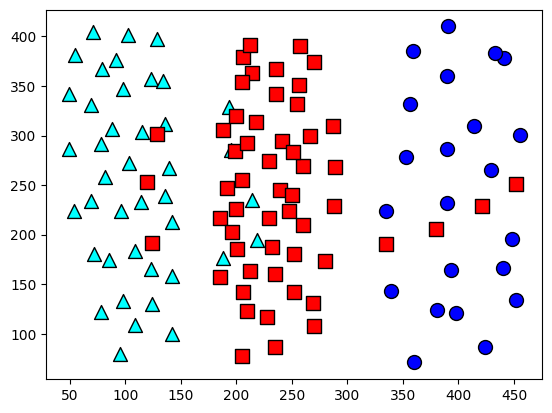

In [7]:
features = dataset[['x_0', 'x_1']]
labels = dataset['y']

plot_points(features, labels)

Построение дерева решений с использованием индекса Джини

In [8]:
decision_tree = DecisionTreeClassifier(max_depth=2)
decision_tree.fit(features.values, labels.values)
decision_tree.score(features.values, labels.values)

0.8983050847457628

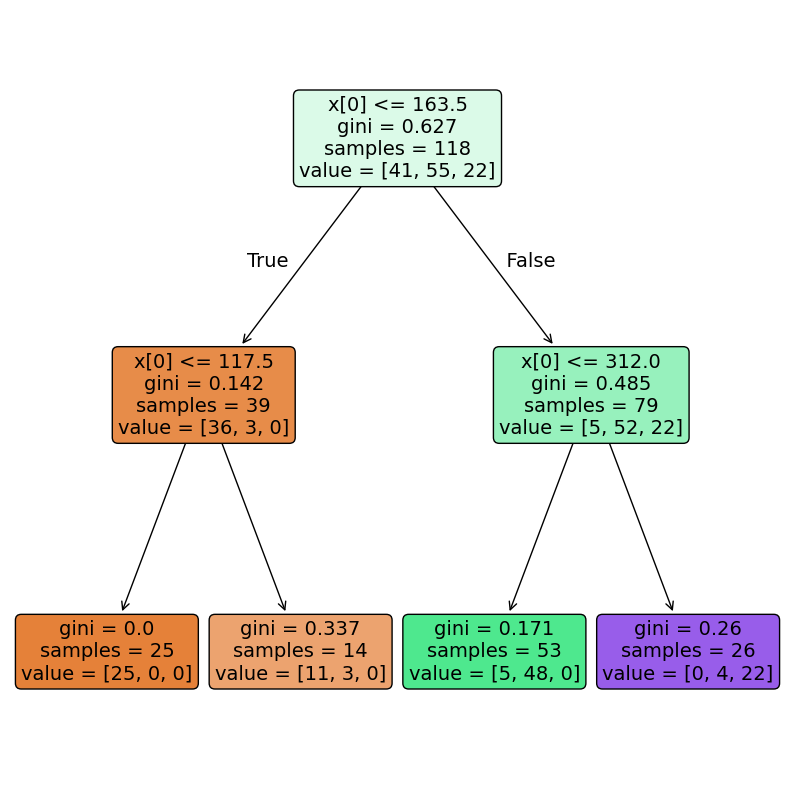

In [9]:
display_tree(decision_tree, 10, 10)

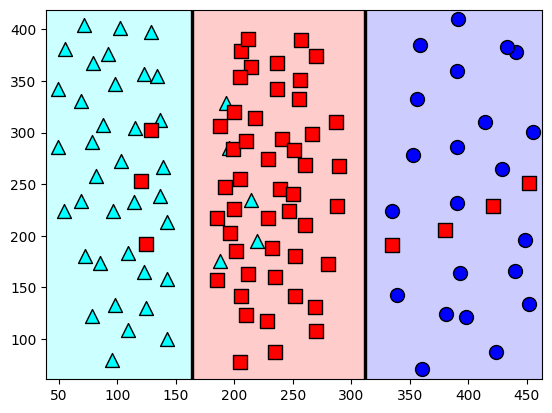

In [10]:
plot_model(features, labels, decision_tree)

Построение дерева решений с использованием энтропии

In [ ]:
decision_tree = DecisionTreeClassifier(max_depth=2, criterion='entropy')
decision_tree.fit(features.values, labels.values)
decision_tree.score(features.values, labels.values)

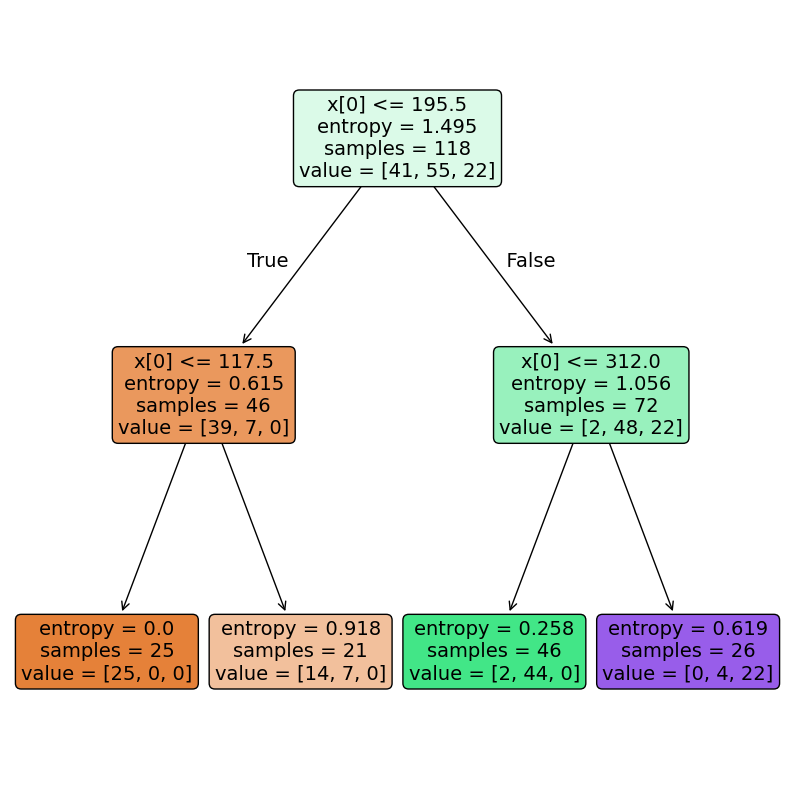

In [26]:
display_tree(decision_tree, 10, 10)

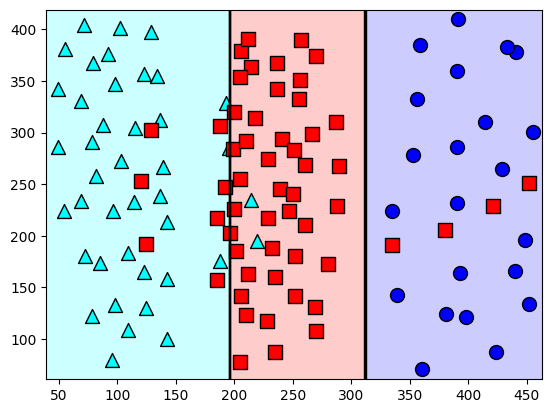

In [27]:
plot_model(features, labels, decision_tree)